# Hakkari / Cilo Buzulları — Google Earth Engine ile Yıllık Alan Ölçümü

**Amaç:** 2000–2024 yılları arasında Hakkari/Cilo Dağları buzullarının yıllık alan değişimini Landsat ve Sentinel-2 uydu görüntüleriyle ölçmek.  
**Yöntem:** NDSI (Normalized Difference Snow Index) eşikleme + manüel GLIMS validasyonu  
**Çıktı:** Yıllık buzul alan zaman serisi → ERA5-Land iklim verisiyle entegrasyon

## ADIM 0: Kurulum ve Kimlik Doğrulama

In [1]:
# Gerekli paketleri kur (ilk çalıştırmada)
# !pip install earthengine-api geemap geopandas folium matplotlib pandas numpy

In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# GEE kimlik doğrulama (ilk çalıştırmada tarayıcı açılır)
try:
    ee.Initialize()
    print('GEE zaten başlatılmış.')
except Exception:
    ee.Authenticate()
    ee.Initialize()
    print('GEE başlatıldı.')

GEE zaten başlatılmış.


## ADIM 1: Çalışma Alanı (ROI) Tanımla

In [3]:
# =============================================================================
# ADIM 1: GLIMS Poligonlarından ROI Oluştur
# Kaynak: hakkari_buzulları_2026.gpkg (2000 src_date, 50m buffer)
# Sadece bilinen buzul alanları analiz edilir — mevsimsel kar dışarıda kalır
# =============================================================================

import os
import geopandas as gpd
from pathlib import Path

GPKG_PATH = Path(os.environ.get('CRYO_GLIMS_GPKG',
                               'data/spatial/hakkari_glaciers_glims.gpkg'))
gdf = gpd.read_file(GPKG_PATH)
# Tüm poligonları kullan (src_date filtresi kaldırıldı)
# Bazı buzullar farklı tarihle girilmiş olabilir
gdf2000 = gdf.copy()

# ~50m buffer — Landsat 30m piksel için gerekli
gdf2000['geometry'] = gdf2000.geometry.buffer(0.0005).simplify(0.0001)
union_geom = gdf2000.geometry.union_all()

# GEE geometrisine çevir
import json as _json
ROI = ee.Geometry(_json.loads(_json.dumps(union_geom.__geo_interface__)))

# GLIMS referans alanları
GLIMS_REF = {
    2000: 3.038,
    2009: 2.826,
}

print(f"Toplam {len(gdf2000)} buzul poligonu yüklendi.")
print(gdf2000[['glac_name','local_id','db_area']].to_string(index=False))
print(f"\nGLIMS referans: 2000={GLIMS_REF[2000]} km², 2009={GLIMS_REF[2009]} km²")
print("ROI: GLIMS 2000 poligonları (50m buffer) — mevsimsel kar elimine edildi.")

Toplam 16 buzul poligonu yüklendi.
          glac_name local_id  db_area
 Izbirak (Gelyasin)     buz8 0.917613
               None     buz7 0.087767
               None    buz10 0.047059
    Uludoruk Middle     buz4 0.339013
        Poyraz Tepe     buz6 0.132581
      Uludoruk West     buz2 0.360204
Erinc (Suppa Durak)     buz1 1.011290
    Uludoruk Middle     buz4 0.353298
      Uludoruk West     buz2 0.415348
               None     buz7 0.135234
        Poyraz Tepe     buz6 0.029078
               None    buz10 0.047059
 Izbirak (Gelyasin)     buz8 0.936877
Erinc (Suppa Durak)     buz1 1.029380
 Izbirak (Gelyasin)     buz8 0.074004
        Poyraz Tepe     buz6 0.150971

GLIMS referans: 2000=3.038 km², 2009=2.826 km²
ROI: GLIMS 2000 poligonları (50m buffer) — mevsimsel kar elimine edildi.


## ADIM 2: Haritada Görselleştir

## ADIM 3: Landsat Koleksiyonlarını Tanımla (2000–2024)

In [4]:
# =============================================================================
# Landsat koleksiyonları (Surface Reflectance, Collection 2 Level-2)
# Dönem: Ağustos-Eylül (buzullar maksimum açıkta, mevsimsel kar minimum)
# =============================================================================

START_MONTH = 8   # Ağustos
END_MONTH   = 9   # Eylül sonu
CLOUD_THR   = 30  # Bulut oranı eşiği (%)

def mask_landsat_clouds(image):
    """Landsat Collection 2 Level-2 bulut maskesi."""
    qa = image.select('QA_PIXEL')
    cloud      = qa.bitwiseAnd(1 << 3).neq(0)
    cloud_shad = qa.bitwiseAnd(1 << 4).neq(0)
    snow       = qa.bitwiseAnd(1 << 5).neq(0)  # kar pikselleri TUTULUR (maskelenmez)
    mask = cloud.Or(cloud_shad).Not()
    return image.updateMask(mask)

def scale_landsat(image):
    """Landsat C2L2 ölçekleme faktörleri."""
    optical = image.select('SR_B.*').multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True)

def get_landsat_collection(year):
    """Yıla göre uygun Landsat koleksiyonunu seç ve döndür."""
    start = f'{year}-{START_MONTH:02d}-01'
    end   = f'{year}-{END_MONTH:02d}-30'

    filters = [
        ee.Filter.bounds(ROI),
        ee.Filter.date(start, end),
        ee.Filter.lt('CLOUD_COVER', CLOUD_THR),
    ]

    if year <= 2012:   # Landsat 5 TM
        col = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
        green_band, swir_band = 'SR_B2', 'SR_B5'
    elif year <= 2013:  # Landsat 7 ETM+
        col = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
        green_band, swir_band = 'SR_B2', 'SR_B5'
    else:              # Landsat 8/9 OLI
        if year <= 2021:
            col = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        else:
            col = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
        green_band, swir_band = 'SR_B3', 'SR_B6'

    col = col.filter(filters).map(mask_landsat_clouds).map(scale_landsat)
    return col, green_band, swir_band

# Test: 2009 için görüntü sayısı
col_test, g, s = get_landsat_collection(2009)
print(f'2009 görüntü sayısı: {col_test.size().getInfo()}')
col_test2, g2, s2 = get_landsat_collection(2020)
print(f'2020 görüntü sayısı: {col_test2.size().getInfo()}')

2009 görüntü sayısı: 5
2020 görüntü sayısı: 8


## ADIM 4: NDSI Hesapla ve Buzul Maskesi Oluştur

In [5]:
# =============================================================================
# ADIM 4: NDSI Hesapla ve Buzul Maskesi Oluştur
# NDSI = (Green - SWIR) / (Green + SWIR)
# Eşik: NDSI > 0.40, yansıma > 0.11
# Yükseklik filtresi: > 2800m (Cilo-Sat buzul dilleri ~2800-3000m'ye iner)
# =============================================================================

NDSI_THRESHOLD = 0.40
DEM = ee.Image('USGS/SRTMGL1_003')
HIGH_ELEV = DEM.gt(2800)  # 2800m üzeri (buzul dilleri bu yüksekliğe kadar iner)

def compute_ndsi(image, green_band, swir_band):
    """NDSI hesapla ve buzul maskesi oluştur."""
    green = image.select(green_band)
    swir  = image.select(swir_band)
    ndsi  = green.subtract(swir).divide(green.add(swir)).rename('NDSI')
    glacier_mask = ndsi.gt(NDSI_THRESHOLD).And(green.gt(0.11)).And(HIGH_ELEV)
    return image.addBands(ndsi).addBands(glacier_mask.rename('glacier_mask'))

def get_glacier_area_km2(year):
    """Belirtilen yıl için buzul alanını km² hesapla."""
    col, green_band, swir_band = get_landsat_collection(year)
    n_images = col.size().getInfo()
    if n_images == 0:
        print(f"  {year}: Görüntü bulunamadı!")
        return None, 0
    composite = col.map(lambda img: compute_ndsi(img, green_band, swir_band)).median()
    glacier_mask = composite.select('glacier_mask')
    area_image = glacier_mask.multiply(ee.Image.pixelArea())
    area_stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ROI,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    area_m2 = area_stats.get('glacier_mask').getInfo()
    area_km2 = area_m2 / 1e6 if area_m2 else 0
    return area_km2, n_images

# Test: GLIMS doğrulaması
print('GLIMS doğrulaması (2000 ve 2009)...')
for yr in [2000, 2009]:
    area, n = get_glacier_area_km2(yr)
    ref = GLIMS_REF.get(yr)
    if area is not None:
        print(f"  {yr}: GEE={area:.3f} km²  |  GLIMS={ref} km²  |  Fark={area-ref:+.3f} km²  ({n} görüntü)")

GLIMS doğrulaması (2000 ve 2009)...
  2000: GEE=2.070 km²  |  GLIMS=3.038 km²  |  Fark=-0.968 km²  (6 görüntü)
  2009: GEE=1.894 km²  |  GLIMS=2.826 km²  |  Fark=-0.932 km²  (5 görüntü)


## ADIM 5: NDSI Eşik Optimizasyonu (GLIMS Kalibrasyonu)

In [6]:
# =============================================================================
# GLIMS 2000 ve 2009 verilerine göre en iyi NDSI eşiğini bul
# =============================================================================

def get_area_with_threshold(year, threshold):
    col, green_band, swir_band = get_landsat_collection(year)
    if col.size().getInfo() == 0:
        return None
    composite = col.map(lambda img: compute_ndsi(img, green_band, swir_band)).median()
    ndsi = composite.select('NDSI')
    green = composite.select(green_band)
    HIGH_ELEV_cal = ee.Image('USGS/SRTMGL1_003').gt(2800)
    mask = ndsi.gt(threshold).And(green.gt(0.11)).And(HIGH_ELEV_cal)
    area_m2 = mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=ROI,
        scale=30, maxPixels=1e9, bestEffort=True
    ).get('NDSI').getInfo()
    return (area_m2 or 0) / 1e6

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
calib_results = []

print('NDSI eşik kalibrasyonu...')
print(f'{"Eşik":>8} | {"2000 GEE":>10} | {"2000 GLIMS":>10} | {"2009 GEE":>10} | {"2009 GLIMS":>10} | {"Toplam Hata":>12}')
print('-'*70)

best_thr, best_err = 0.40, float('inf')

for thr in thresholds:
    a2000 = get_area_with_threshold(2000, thr)
    a2009 = get_area_with_threshold(2009, thr)
    if a2000 and a2009:
        err = abs(a2000 - GLIMS_REF[2000]) + abs(a2009 - GLIMS_REF[2009])
        calib_results.append({'threshold': thr, 'area_2000': a2000, 'area_2009': a2009, 'total_error': err})
        flag = ' <-- EN İYİ' if err < best_err else ''
        if err < best_err:
            best_err, best_thr = err, thr
        print(f'{thr:>8.2f} | {a2000:>10.3f} | {GLIMS_REF[2000]:>10.3f} | {a2009:>10.3f} | {GLIMS_REF[2009]:>10.3f} | {err:>12.3f}{flag}')

NDSI_THRESHOLD = best_thr
print(f'\nKullanılacak NDSI eşiği: {NDSI_THRESHOLD}')

NDSI eşik kalibrasyonu...
    Eşik |   2000 GEE | 2000 GLIMS |   2009 GEE | 2009 GLIMS |  Toplam Hata
----------------------------------------------------------------------
    0.20 |      2.365 |      3.038 |      2.247 |      2.826 |        1.252 <-- EN İYİ
    0.25 |      2.300 |      3.038 |      2.189 |      2.826 |        1.375
    0.30 |      2.231 |      3.038 |      2.115 |      2.826 |        1.518
    0.35 |      2.167 |      3.038 |      2.029 |      2.826 |        1.668
    0.40 |      2.097 |      3.038 |      1.936 |      2.826 |        1.831
    0.45 |      2.031 |      3.038 |      1.810 |      2.826 |        2.022
    0.50 |      1.938 |      3.038 |      1.667 |      2.826 |        2.259
    0.55 |      1.788 |      3.038 |      1.477 |      2.826 |        2.599

Kullanılacak NDSI eşiği: 0.2


## ADIM 6: 2000–2024 Yıllık Alan Hesaplama

In [7]:
# =============================================================================
# Tüm yıllar için buzul alanı hesapla
# NOT: Her yıl ~3-5 saniye sürebilir (~2 dakika toplam)
# =============================================================================

YEARS = list(range(2000, 2025))
results = []

print('Yıllık buzul alanı hesaplanıyor...')
print(f'{"Yıl":>6} | {"Alan (km²)":>12} | {"Görüntü":>8} | {"Durum"}')
print('-'*50)

for year in YEARS:
    area, n_img = get_glacier_area_km2(year)
    
    status = 'OK' if area and area > 0.5 else ('Düsük alan - kontrol et' if area else 'VERİ YOK')
    glims_flag = f' [GLIMS={GLIMS_REF[year]:.3f}]' if year in GLIMS_REF else ''
    
    results.append({
        'year': year,
        'area_km2': area,
        'n_images': n_img,
        'status': status,
        'glims_ref': GLIMS_REF.get(year)
    })
    print(f'{year:>6} | {str(round(area,3) if area else "N/A"):>12} | {n_img:>8} | {status}{glims_flag}')

df_glacier = pd.DataFrame(results)
df_glacier = df_glacier[df_glacier['area_km2'].notna() & (df_glacier['area_km2'] > 0)]
print(f'\nGeçerli yıl sayısı: {len(df_glacier)}')
print(df_glacier[['year','area_km2','n_images']].to_string(index=False))

Yıllık buzul alanı hesaplanıyor...
   Yıl |   Alan (km²) |  Görüntü | Durum
--------------------------------------------------
  2000 |        2.338 |        6 | OK [GLIMS=3.038]
  2001 |        2.658 |        5 | OK
  2002 |        3.266 |        1 | OK
  2003 |        2.119 |        1 | OK
  2004 |        2.633 |        5 | OK
  2005 |        2.478 |        6 | OK
  2006 |        2.512 |        6 | OK
  2007 |        2.249 |        7 | OK
  2008 |        1.921 |        3 | OK
  2009 |        2.225 |        5 | OK [GLIMS=2.826]
  2010 |          2.8 |        4 | OK
  2011 |        2.107 |        5 | OK
  2012: Görüntü bulunamadı!
  2012 |          N/A |        0 | VERİ YOK
  2013 |        2.367 |        7 | OK
  2014 |        1.869 |        8 | OK
  2015 |        1.919 |        6 | OK
  2016 |        2.256 |        8 | OK
  2017 |         2.04 |        7 | OK
  2018 |        1.924 |        7 | OK
  2019 |        2.542 |        8 | OK
  2020 |        2.166 |        8 | OK
  2021 |     

## ADIM 7: Sentinel-2 ile 2017–2024 Doğrulaması

In [8]:
# =============================================================================
# Sentinel-2 (10m çözünürlük) ile Landsat sonuçlarını karşılaştır
# Sentinel-2: 2017'den itibaren mevcut
# =============================================================================

def mask_s2_clouds(image):
    scl = image.select('SCL')
    # SCL: 4=bitki, 5=çıplak, 6=su, 8=orta bulut, 9=yüksek bulut, 11=kar/buz
    mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(3))
    return image.updateMask(mask).divide(10000)

def get_s2_glacier_area(year):
    """Sentinel-2 SR ile buzul alanı (2017+)."""
    start = f'{year}-08-01'
    end   = f'{year}-09-30'
    
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(ROI)
           .filterDate(start, end)
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
           .map(mask_s2_clouds))
    
    n = col.size().getInfo()
    if n == 0:
        return None, 0
    
    composite = col.median()
    green = composite.select('B3')  # 560nm
    swir  = composite.select('B11') # 1610nm
    ndsi  = green.subtract(swir).divide(green.add(swir))
    mask  = ndsi.gt(NDSI_THRESHOLD).And(green.gt(0.11))
    
    area_m2 = mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=ROI,
        scale=10, maxPixels=1e9, bestEffort=True
    ).get('B3').getInfo()
    
    return (area_m2 or 0) / 1e6, n

s2_results = []
print('Sentinel-2 doğrulaması (2017–2024)...')
print(f'{"Yıl":>6} | {"S2 Alan (km²)":>14} | {"LS Alan (km²)":>14} | {"Fark":>8}')
print('-'*55)

for year in range(2017, 2025):
    s2_area, n = get_s2_glacier_area(year)
    ls_row = df_glacier[df_glacier['year'] == year]
    ls_area = ls_row['area_km2'].values[0] if len(ls_row) > 0 else None
    
    if s2_area and ls_area:
        diff = s2_area - ls_area
        s2_results.append({'year': year, 's2_area': s2_area, 'ls_area': ls_area})
        print(f'{year:>6} | {s2_area:>14.3f} | {ls_area:>14.3f} | {diff:>+8.3f}')
    elif s2_area:
        print(f'{year:>6} | {s2_area:>14.3f} | {"N/A":>14} | {"N/A":>8}')

df_s2 = pd.DataFrame(s2_results)

Sentinel-2 doğrulaması (2017–2024)...
   Yıl |  S2 Alan (km²) |  LS Alan (km²) |     Fark
-------------------------------------------------------
  2017 |          2.233 |          2.040 |   +0.193
  2018 |          2.136 |          1.924 |   +0.213
  2019 |          2.975 |          2.542 |   +0.433
  2020 |          2.549 |          2.166 |   +0.383
  2021 |          2.061 |          1.670 |   +0.390
  2022 |          2.017 |          1.632 |   +0.385
  2023 |          2.048 |          1.737 |   +0.311
  2024 |          2.598 |          2.217 |   +0.381


## ADIM 8: Zaman Serisi Analizi ve Görselleştirme

TREND ANALİZİ
Dönem: 2000–2024
Başlangıç alanı : 2.338 km²
Bitiş alanı     : 2.217 km²
Toplam değişim  : -0.121 km² (-5.2%)
Yıllık değişim  : -0.0315 km²/yıl
R²              : 0.379
Mann-Kendall p  : 0.0027 (anlamlı, α=0.05)

Grafik kaydedildi: graphics/glacier_area_timeseries.png


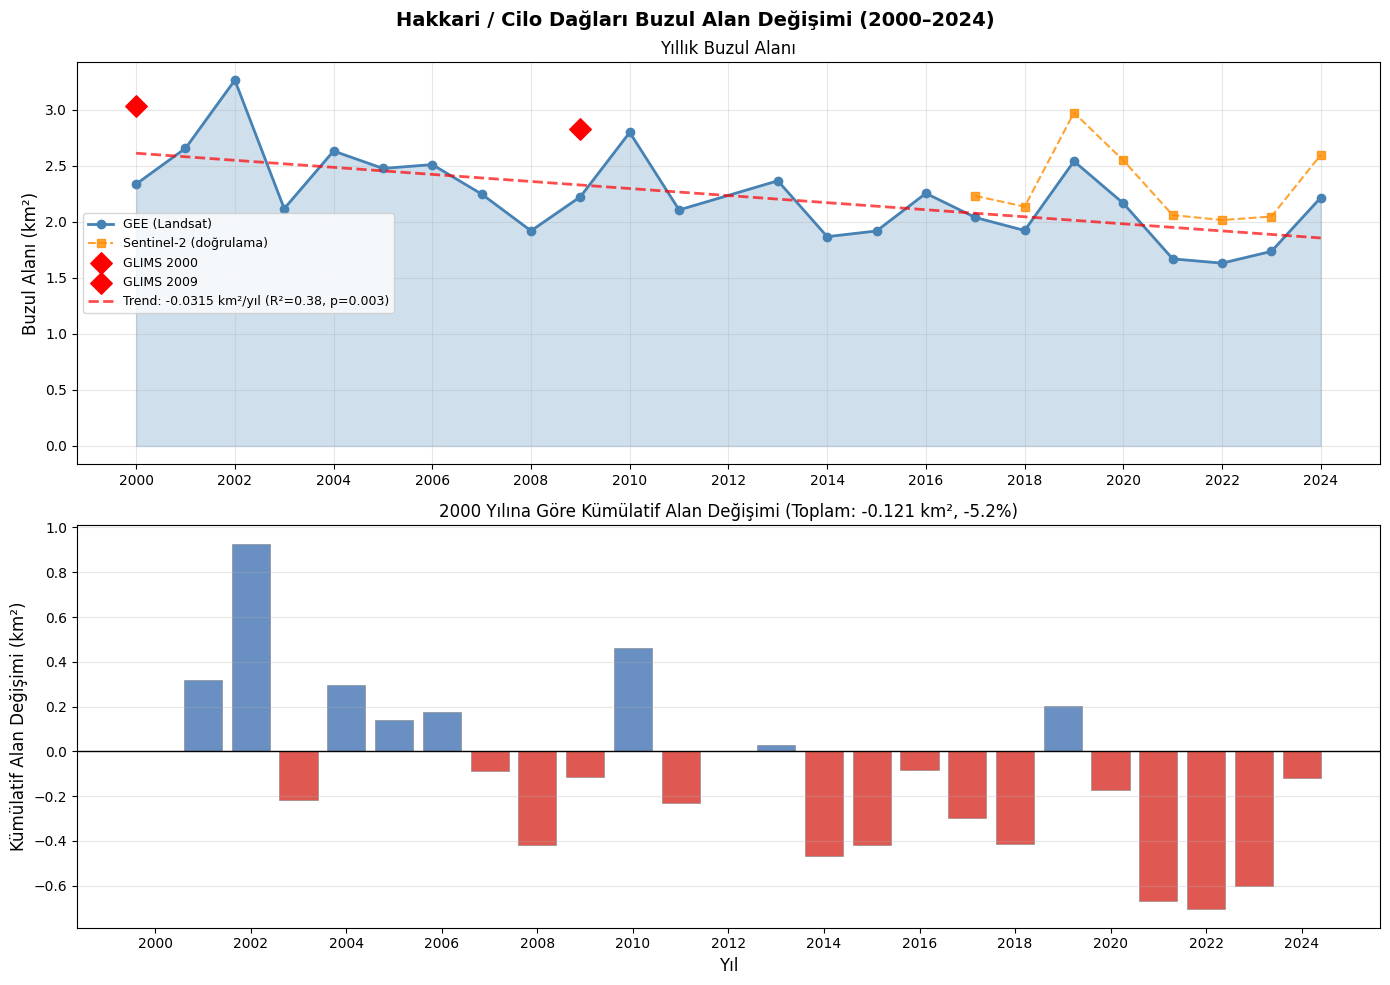

İnteraktif grafik kaydedildi (TR): graphics/tr/html/glacier_area_timeseries_interactive.html
Interactive plot saved (EN): graphics/eng/html/glacier_area_timeseries_interactive.html


In [9]:
# =============================================================================
# Trend analizi ve görselleştirme
# =============================================================================

from scipy import stats

years_arr = df_glacier['year'].values
areas_arr = df_glacier['area_km2'].values

# Mann-Kendall trend testi
def mannkendall(x):
    n = len(x)
    s = sum(np.sign(x[j] - x[i]) for i in range(n-1) for j in range(i+1, n))
    var_s = n * (n-1) * (2*n+5) / 18
    z = (s - np.sign(s)) / np.sqrt(var_s)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return s, z, p

slope, intercept, r, p_lr, se = stats.linregress(years_arr, areas_arr)
mk_s, mk_z, mk_p = mannkendall(areas_arr)
trend_line = slope * years_arr + intercept

total_loss = areas_arr[-1] - areas_arr[0]
pct_loss   = total_loss / areas_arr[0] * 100
ann_loss   = slope  # km²/yıl

print('TREND ANALİZİ')
print('='*50)
print(f'Dönem: {years_arr[0]}–{years_arr[-1]}')
print(f'Başlangıç alanı : {areas_arr[0]:.3f} km²')
print(f'Bitiş alanı     : {areas_arr[-1]:.3f} km²')
print(f'Toplam değişim  : {total_loss:+.3f} km² ({pct_loss:+.1f}%)')
print(f'Yıllık değişim  : {ann_loss:+.4f} km²/yıl')
print(f'R²              : {r**2:.3f}')
print(f'Mann-Kendall p  : {mk_p:.4f} ({"anlamlı" if mk_p < 0.05 else "anlamsız"}, α=0.05)')

# =============================================================================
# Grafik
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Hakkari / Cilo Dağları Buzul Alan Değişimi (2000–2024)',
             fontsize=14, fontweight='bold')

# --- Panel 1: Alan zaman serisi ---
ax1 = axes[0]
ax1.fill_between(years_arr, areas_arr, alpha=0.25, color='steelblue')
ax1.plot(years_arr, areas_arr, 'o-', color='steelblue', lw=2, ms=6, label='GEE (Landsat)')

if len(df_s2) > 0:
    ax1.plot(df_s2['year'], df_s2['s2_area'], 's--', color='darkorange',
             lw=1.5, ms=6, alpha=0.8, label='Sentinel-2 (doğrulama)')

# GLIMS referans noktaları
for yr, val in GLIMS_REF.items():
    ax1.scatter(yr, val, s=120, zorder=5, color='red',
                marker='D', label=f'GLIMS {yr}' if yr == list(GLIMS_REF.keys())[0] else f'GLIMS {yr}')

ax1.plot(years_arr, trend_line, 'r--', lw=2, alpha=0.7,
         label=f'Trend: {slope:+.4f} km²/yıl (R²={r**2:.2f}, p={mk_p:.3f})')

ax1.set_ylabel('Buzul Alanı (km²)', fontsize=12)
ax1.set_title('Yıllık Buzul Alanı')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

# --- Panel 2: Kümülatif alan kaybı ---
ax2 = axes[1]
cum_loss = (areas_arr - areas_arr[0])
ax2.bar(years_arr, cum_loss,
        color=['#d73027' if v < 0 else '#4575b4' for v in cum_loss],
        alpha=0.8, edgecolor='gray', linewidth=0.5)
ax2.axhline(0, color='black', lw=1)
ax2.set_xlabel('Yıl', fontsize=12)
ax2.set_ylabel('Kümülatif Alan Değişimi (km²)', fontsize=12)
ax2.set_title(f'2000 Yılına Göre Kümülatif Alan Değişimi (Toplam: {total_loss:+.3f} km², {pct_loss:+.1f}%)')
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()

# Kaydet
out_dir = Path('graphics')
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / 'glacier_area_timeseries.png', dpi=300, bbox_inches='tight')
print('\nGrafik kaydedildi: graphics/glacier_area_timeseries.png')
plt.show()

# --- İnteraktif Plotly sürümü (legend / başlık / annotation taşınabilir) ---
fig_int = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=('Yıllık Buzul Alanı',
                                        f'2000 Yılına Göre Kümülatif Alan Değişimi (Toplam: {total_loss:+.3f} km², {pct_loss:+.1f}%)'))
fig_int.add_trace(
    go.Scatter(x=years_arr, y=areas_arr, mode='lines', line=dict(color='steelblue', width=2),
               name='Alan (dolgu için alt çizgi)', showlegend=False, hovertemplate='Yıl=%{x}<br>Alan=%{y:.3f} km²<extra></extra>',
               fill='tozeroy', fillcolor='rgba(70,130,180,0.25)'),
    row=1, col=1
)
fig_int.add_trace(
    go.Scatter(x=years_arr, y=areas_arr, mode='lines+markers',
               line=dict(color='steelblue', width=2), marker=dict(size=7),
               name='GEE (Landsat)', hovertemplate='Yıl=%{x}<br>Alan=%{y:.3f} km²<extra></extra>'),
    row=1, col=1
)
if len(df_s2) > 0:
    fig_int.add_trace(
        go.Scatter(x=df_s2['year'], y=df_s2['s2_area'], mode='lines+markers',
                   line=dict(color='darkorange', width=1.5, dash='dash'), marker=dict(symbol='square', size=8),
                   name='Sentinel-2 (doğrulama)', hovertemplate='Yıl=%{x}<br>S2 alan=%{y:.3f} km²<extra></extra>'),
        row=1, col=1
    )
for yr, val in GLIMS_REF.items():
    fig_int.add_trace(
        go.Scatter(x=[yr], y=[val], mode='markers', marker=dict(color='red', size=11, symbol='diamond'),
                   name=f'GLIMS {yr}', hovertemplate='Yıl=%{x}<br>GLIMS=%{y:.3f} km²<extra></extra>'),
        row=1, col=1
    )
fig_int.add_trace(
    go.Scatter(x=years_arr, y=trend_line, mode='lines',
               line=dict(color='red', width=2, dash='dash'),
               name=f'Trend: {slope:+.4f} km²/yıl (R²={r**2:.2f}, p={mk_p:.3f})',
               hovertemplate='Yıl=%{x}<br>Trend=%{y:.3f} km²<extra></extra>'),
    row=1, col=1
)
fig_int.add_trace(
    go.Bar(x=years_arr, y=cum_loss,
           marker_color=['#d73027' if v < 0 else '#4575b4' for v in cum_loss],
           marker_line_color='gray', marker_line_width=0.5, opacity=0.8,
           name='Kümülatif Alan Değişimi', hovertemplate='Yıl=%{x}<br>Değişim=%{y:.3f} km²<extra></extra>'),
    row=2, col=1
)
fig_int.add_hline(y=0, line_width=1, line_color='black', row=2, col=1)
fig_int.update_xaxes(title_text='Yıl', dtick=2, row=2, col=1)
fig_int.update_yaxes(title_text='Buzul Alanı (km²)', row=1, col=1)
fig_int.update_yaxes(title_text='Kümülatif Alan Değişimi (km²)', row=2, col=1)
fig_int.update_layout(height=780, width=1200,
                      title='Hakkari / Cilo Dağları Buzul Alan Değişimi (2000–2024)',
                      legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
                      template='plotly_white')
html_dir_tr = out_dir / 'tr' / 'html'
html_dir_en = out_dir / 'eng' / 'html'
html_dir_tr.mkdir(parents=True, exist_ok=True)
html_dir_en.mkdir(parents=True, exist_ok=True)
html_path_tr = html_dir_tr / 'glacier_area_timeseries_interactive.html'
fig_int.write_html(html_path_tr, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
print(f'İnteraktif grafik kaydedildi (TR): {html_path_tr}')
fig_int_en = go.Figure(fig_int)
fig_int_en.update_layout(title='Hakkari / Cilo Mountains Glacier Area Change (2000–2024)')
fig_int_en.update_yaxes(title_text='Glacier Area (km²)', row=1, col=1)
fig_int_en.update_yaxes(title_text='Cumulative Area Change (km²)', row=2, col=1)
fig_int_en.update_xaxes(title_text='Year', row=2, col=1)
fig_int_en.layout.annotations[0].update(text='Annual Glacier Area')
fig_int_en.layout.annotations[1].update(text=f'Cumulative Area Change Relative to 2000 (Total: {total_loss:+.3f} km², {pct_loss:+.1f}%)')
fig_int_en.data[1].name = 'GEE (Landsat)'
if len(df_s2) > 0:
    fig_int_en.data[2].name = 'Sentinel-2 (validation)'
trend_idx = 3 + (len(df_s2) > 0) + len(GLIMS_REF) - 1
fig_int_en.data[trend_idx].name = f'Trend: {slope:+.4f} km²/yr (R²={r**2:.2f}, p={mk_p:.3f})'
fig_int_en.data[-1].name = 'Cumulative Area Change'
html_path_en = html_dir_en / 'glacier_area_timeseries_interactive.html'
fig_int_en.write_html(html_path_en, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
print(f'Interactive plot saved (EN): {html_path_en}')
fig_int.show(config={'editable': True, 'scrollZoom': True, 'displaylogo': False})

## ADIM 9: ERA5-Land ile Korelasyon Analizi

In [10]:
# =============================================================================
# ADIM 9: ERA5-Land yıllık değerleri yükle ve buzul alanıyla ilişkilendir
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import os

# Doğru data klasörünü bul (notebook nerede çalışırsa çalışsın)
def _find_data_dir():
    candidates = [
        Path('data'),                                          # notebook dizininden
        Path('era5_land_base_data/ERA5_Land/data'),           # proje kökünden
        Path(__import__('os').getcwd()) / 'data',
    ]
    for p in candidates:
        if (p / 'hakkari_gunluk_tum_degiskenler.csv').exists():
            return p
    raise FileNotFoundError(
        'data/ klasörü bulunamadı.\n'
        'Notebook ile aynı dizinde veya proje kökünde çalıştır.'
    )

DATA_DIR    = _find_data_dir()
ERA5_CSV    = DATA_DIR / 'hakkari_gunluk_tum_degiskenler.csv'
GLACIER_CSV = DATA_DIR / 'hakkari_glacier_area_2000_2024.csv'
print(f'Data dizini: {DATA_DIR.resolve()}')

# ERA5 yükle (önce hafızadan, yoksa CSV'den)
try:
    era5 = df_daily.copy()
    print('df_daily hafızadan yüklendi.')
except NameError:
    era5 = pd.read_csv(ERA5_CSV, sep=';', index_col=0, parse_dates=True)
    print(f'ERA5 CSV yüklendi: {len(era5)} gün')

# Buzul zaman serisi
df_glacier = pd.read_csv(GLACIER_CSV)
# year sütunu yoksa index'ten geri yükle
if 'year' not in df_glacier.columns:
    years = [y for y in range(2000, 2025) if y != 2012]
    df_glacier.insert(0, 'year', years[:len(df_glacier)])
print(f'Buzul CSV yüklendi: {len(df_glacier)} yıl  '
      f'({df_glacier.area_km2.min():.3f}–{df_glacier.area_km2.max():.3f} km²)')

# Mevsimsel ERA5 yıllık değerler
def season_agg(df, months):
    s = df[df.index.month.isin(months)]
    return s.groupby(s.index.year).agg(
        sicaklik=('t2m_C',   'mean'),
        yagis=   ('tp_mm',   'sum'),
        karErimesi=('smlt_mm','sum'),
        karOrtusu= ('snowc',  'mean'),
        karDerinligi=('sd',   'mean'),
    )

era5_ann = season_agg(era5, range(1,13)).add_prefix('ann_')
era5_mam = season_agg(era5, [3,4,5]).add_prefix('mam_')
era5_djf = season_agg(era5, [12,1,2]).add_prefix('djf_')

era5_combined = era5_ann.join(era5_mam).join(era5_djf)
era5_combined.index.name = 'year'

# year'ı index yap (zaten index ise reset et)
df_g = df_glacier.set_index('year') if 'year' in df_glacier.columns else df_glacier
df_merge = df_g.join(era5_combined, how='inner')
print(f'Birleştirilen yıl sayısı: {len(df_merge)}')
print(df_merge[['area_km2','ann_sicaklik','ann_karDerinligi','djf_karDerinligi']].describe().round(3))


Data dizini: data
ERA5 CSV yüklendi: 27759 gün
Buzul CSV yüklendi: 24 yıl  (1.322–2.576 km²)
Birleştirilen yıl sayısı: 24
       area_km2  ann_sicaklik  ann_karDerinligi  djf_karDerinligi
count    24.000        24.000            24.000            24.000
mean      1.814         4.636             0.150             0.228
std       0.293         0.715             0.047             0.065
min       1.322         3.350             0.069             0.139
25%       1.622         4.129             0.116             0.181
50%       1.804         4.681             0.140             0.207
75%       1.987         5.050             0.182             0.266
max       2.576         6.058             0.261             0.351


BUZUL ALANI vs ERA5-LAND KORELASYONLARı (n=24 yıl)
Değişken                                 r         p  sig
-----------------------------------------------------------------
  Yıllık Sıcaklık (°C)              r=-0.234  p=0.2705  ns
  Yıllık Kar Derinliği (m)          r=+0.545  p=0.0059  **
  Kış Kar Derinliği (m)             r=+0.592  p=0.0023  **
  İlkbahar Kar Erimesi (mm)         r=+0.509  p=0.0112  *
  İlkbahar Kar Örtüsü (%)           r=+0.415  p=0.0438  *
  İlkbahar Kar Derinliği (m)        r=+0.455  p=0.0256  *


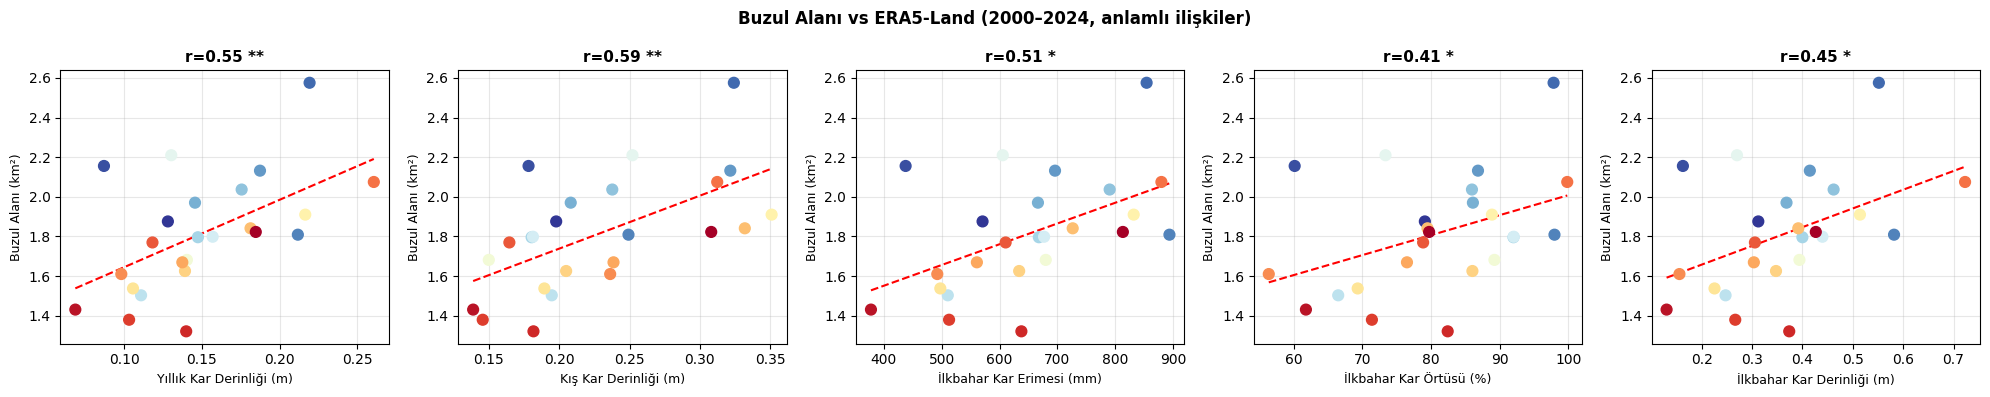


Grafik kaydedildi: graphics/glacier_era5_correlation.png
İnteraktif grafik kaydedildi (TR): graphics/tr/html/glacier_era5_correlation_interactive.html
Interactive plot saved (EN): graphics/eng/html/glacier_era5_correlation_interactive.html


In [12]:
# =============================================================================
# ADIM 9b: Korelasyon analizi — Buzul Alanı vs ERA5-Land Değişkenleri
# =============================================================================
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

if 'df_merge' not in dir() or len(df_merge) < 5:
    print("df_merge eksik — önce ADIM 9'u çalıştır.")
else:
    CORR_VARS = {
        'ann_sicaklik'    : 'Yıllık Sıcaklık (°C)',
        'ann_karDerinligi': 'Yıllık Kar Derinliği (m)',
        'djf_karDerinligi': 'Kış Kar Derinliği (m)',
        'mam_karErimesi'  : 'İlkbahar Kar Erimesi (mm)',
        'mam_karOrtusu'   : 'İlkbahar Kar Örtüsü (%)',
        'mam_karDerinligi': 'İlkbahar Kar Derinliği (m)',
    }

    print("=" * 65)
    print("BUZUL ALANI vs ERA5-LAND KORELASYONLARı (n=24 yıl)")
    print("=" * 65)
    print(f"{'Değişken':<35} {'r':>6}  {'p':>8}  sig")
    print("-" * 65)

    plot_vars = []
    for var, lbl in CORR_VARS.items():
        if var not in df_merge.columns:
            continue
        x = df_merge[var].values
        y = df_merge['area_km2'].values
        valid = ~(np.isnan(x) | np.isnan(y)) & (np.std(x) > 0)
        if valid.sum() < 5:
            continue
        r, p = stats.pearsonr(x[valid], y[valid])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {lbl:<33} r={r:+.3f}  p={p:.4f}  {sig}")
        if sig != 'ns':
            plot_vars.append((var, lbl, r, p))

    print("=" * 65)

    # --- Sadece anlamlı değişkenleri çiz ---
    if not plot_vars:
        print("Anlamlı korelasyon bulunamadı.")
    else:
        fig, axes = plt.subplots(1, len(plot_vars), figsize=(4*len(plot_vars), 4))
        if len(plot_vars) == 1:
            axes = [axes]
        fig.suptitle('Buzul Alanı vs ERA5-Land (2000–2024, anlamlı ilişkiler)',
                     fontsize=12, fontweight='bold')

        for ax, (var, lbl, r_val, p_val) in zip(axes, plot_vars):
            x = df_merge[var].values
            y = df_merge['area_km2'].values
            valid = ~(np.isnan(x) | np.isnan(y))
            x, y = x[valid], y[valid]
            m, b = np.polyfit(x, y, 1)
            ax.scatter(x, y, c=df_merge.index[valid], cmap='RdYlBu_r', s=60, zorder=3)
            ax.plot(np.sort(x), m*np.sort(x)+b, 'r--', lw=1.5)
            ax.set_xlabel(lbl, fontsize=9)
            ax.set_ylabel('Buzul Alanı (km²)', fontsize=9)
            sig = '***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'
            ax.set_title(f'r={r_val:.2f} {sig}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        # Grafik çıktı yolu — notebook dizininden
        import os
        out_dir = DATA_DIR.parent / 'graphics' if 'DATA_DIR' in dir() else Path('graphics')
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / 'glacier_era5_correlation.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'\nGrafik kaydedildi: {out_path}')

        # --- İnteraktif Plotly sürümü ---
        fig_int = make_subplots(rows=1, cols=len(plot_vars), subplot_titles=[lbl for _, lbl, _, _ in plot_vars])
        for i, (var, lbl, r_val, p_val) in enumerate(plot_vars, start=1):
            x = df_merge[var].values
            y = df_merge['area_km2'].values
            valid = ~(np.isnan(x) | np.isnan(y))
            x, y = x[valid], y[valid]
            years_valid = df_merge.index[valid]
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(float(np.min(x)), float(np.max(x)), 100)
            fig_int.add_trace(
                go.Scatter(x=x, y=y, mode='markers',
                           marker=dict(size=10, color=years_valid, colorscale='RdYlBu_r', showscale=(i == len(plot_vars)),
                                       colorbar=dict(title='Yıl') if i == len(plot_vars) else None),
                           text=[str(yy) for yy in years_valid],
                           hovertemplate='Yıl=%{text}<br>' + lbl + '=%{x:.3f}<br>Buzul Alanı=%{y:.3f} km²<extra></extra>',
                           name=lbl),
                row=1, col=i
            )
            fig_int.add_trace(
                go.Scatter(x=xs, y=m*xs+b, mode='lines',
                           line=dict(color='red', width=2, dash='dash'),
                           name=f'{lbl} trend',
                           hovertemplate='Trend<extra></extra>', showlegend=False),
                row=1, col=i
            )
            sig = '***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else 'ns'
            fig_int.update_xaxes(title_text=lbl, row=1, col=i)
            fig_int.update_yaxes(title_text='Buzul Alanı (km²)', row=1, col=i)
            xref_dom = 'x domain' if i == 1 else f'x{i} domain'
            fig_int.add_annotation(x=0.5, y=1.08, xref=xref_dom, yref='paper',
                                   text=f'r={r_val:.2f} {sig}', showarrow=False, font=dict(size=12))
        fig_int.update_layout(height=460, width=max(420*len(plot_vars), 900),
                              title='Buzul Alanı vs ERA5-Land (2000–2024, anlamlı ilişkiler)',
                              template='plotly_white')
        html_dir_tr = out_dir / 'tr' / 'html'
        html_dir_en = out_dir / 'eng' / 'html'
        html_dir_tr.mkdir(parents=True, exist_ok=True)
        html_dir_en.mkdir(parents=True, exist_ok=True)
        html_out_tr = html_dir_tr / 'glacier_era5_correlation_interactive.html'
        fig_int.write_html(html_out_tr, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
        print(f'İnteraktif grafik kaydedildi (TR): {html_out_tr}')
        fig_int_en = go.Figure(fig_int)
        fig_int_en.update_layout(title='Glacier Area vs ERA5-Land (2000–2024, significant relationships)')
        for i, (_, lbl, _, _) in enumerate(plot_vars, start=1):
            lbl_en = (lbl.replace('Yıllık Sıcaklık', 'Annual Temperature')
                        .replace('Yıllık Kar Derinliği', 'Annual Snow Depth')
                        .replace('Kış Kar Derinliği', 'Winter Snow Depth')
                        .replace('İlkbahar Kar Erimesi', 'Spring Snowmelt')
                        .replace('İlkbahar Kar Örtüsü', 'Spring Snow Cover')
                        .replace('İlkbahar Kar Derinliği', 'Spring Snow Depth')
                        .replace('(°C)', '(°C)').replace('(m)', '(m)').replace('(mm)', '(mm)').replace('(%)', '(%)'))
            fig_int_en.update_xaxes(title_text=lbl_en, row=1, col=i)
            fig_int_en.update_yaxes(title_text='Glacier Area (km²)', row=1, col=i)
            fig_int_en.layout.annotations[i-1].update(text=lbl_en)
        html_out_en = html_dir_en / 'glacier_era5_correlation_interactive.html'
        fig_int_en.write_html(html_out_en, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
        print(f'Interactive plot saved (EN): {html_out_en}')
        fig_int.show(config={'editable': True, 'scrollZoom': True, 'displaylogo': False})


## ADIM 12: SPEI–Buzul Korelasyonu ve Makale İçin İstatistik Özeti

In [ ]:
# =============================================================================
# ADIM 12: SPEI–Buzul Alanı Korelasyon Analizi
#          ERA5 notebookundan hesaplanan SPEI serisi (ADIM 21) kullanılır.
#          Makale SPEI Results bölümü için sayısal doğrulama.
# =============================================================================
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Veri yükle ────────────────────────────────────────────────────────────────
def _find_data_dir():
    candidates = [
        Path('data'),
        Path('era5_land_base_data/ERA5_Land/data'),
        Path(__import__('os').getcwd()) / 'data',
    ]
    for p in candidates:
        if (p / 'hakkari_spei_sonuclari.csv').exists():
            return p
    raise FileNotFoundError(
        "hakkari_spei_sonuclari.csv bulunamadı.\n"
        "Önce ERA5 notebook ADIM 21'i çalıştırın."
    )

DATA_DIR = _find_data_dir()

df_spei    = pd.read_csv(DATA_DIR / 'hakkari_spei_sonuclari.csv',
                         sep=';', index_col=0, parse_dates=True)
_df_gl = pd.read_csv(DATA_DIR / 'hakkari_glacier_area_2000_2024.csv')
if 'year' not in _df_gl.columns:
    _df_gl.insert(0, 'year', [y for y in range(2000,2025) if y != 2012][:len(_df_gl)])
df_glacier = _df_gl.set_index('year')
print(f"SPEI yüklendi   : {df_spei.index[0].date()} – {df_spei.index[-1].date()}")
print(f"Buzul CSV       : {len(df_glacier)} yıl  "
      f"({df_glacier.area_km2.min():.3f}–{df_glacier.area_km2.max():.3f} km²)")

# ── Yıllık SPEI ortalamaları ──────────────────────────────────────────────────
# SPEI-24 yaz ortalaması (Tem-Eyl) — erima mevsimi
mask_jas = df_spei.index.month.isin([7, 8, 9])
spei24_jas = (df_spei.loc[mask_jas, 'SPEI_24']
              .groupby(df_spei.loc[mask_jas].index.year).mean())
spei24_jas.name = 'SPEI24_JAS'

# SPEI-12 yıllık ortalama
spei12_ann = df_spei['SPEI_12'].resample('YE').mean()
spei12_ann.index = spei12_ann.index.year
spei12_ann.name = 'SPEI12_ann'

# SPEI-3 yıllık ortalama
spei3_ann = df_spei['SPEI_3'].resample('YE').mean()
spei3_ann.index = spei3_ann.index.year
spei3_ann.name = 'SPEI3_ann'

# Birleştir
df_m = df_glacier[['area_km2']].join(
    pd.concat([spei24_jas, spei12_ann, spei3_ann], axis=1)
).dropna()

print(f"Ortak yıl sayısı: {len(df_m)}  ({df_m.index.min()}–{df_m.index.max()})")

# ── Pearson korelasyonları ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("SPEI – BUZUL ALANI PEARSONKORELASYONLARı")
print("="*65)
for var, lbl in [
    ('SPEI24_JAS', 'SPEI-24 Yaz (Tem-Eyl)'),
    ('SPEI12_ann', 'SPEI-12 Yıllık ort.  '),
    ('SPEI3_ann',  'SPEI-3  Yıllık ort.  '),
]:
    x = df_m[var].values
    y = df_m['area_km2'].values
    r, p = stats.pearsonr(x, y)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {lbl} : r={r:+.3f}  p={p:.4f}  {sig}")

# ── En düşük buzul yılları + SPEI bağlamı ─────────────────────────────────────
print("\n" + "="*65)
print("EN DÜŞÜK 5 BUZUL ALANI YILI — SPEI-24 YAZ DEĞERLERİ")
print("="*65)
top5 = df_glacier['area_km2'].nsmallest(5)
for yr, area in top5.items():
    s24 = spei24_jas.get(yr, np.nan)
    s12 = spei12_ann.get(yr, np.nan)
    print(f"  {yr}: {area:.3f} km²  |  SPEI-24 yaz={s24:+.2f}  SPEI-12={s12:+.2f}")

# ── SPEI-24 < -1.5 (kurak) dönemler (1950–2025) ───────────────────────────────
print("\n" + "="*65)
print("SPEI-24 ≤ -1.5 (Şiddetli Kurak) DÖNEMLERİ")
print("="*65)
extreme = df_spei[df_spei['SPEI_24'] <= -1.5]['SPEI_24']
# Grupla ─ ardışık aylar
groups = (extreme.index.to_series().diff() > pd.Timedelta('40d')).cumsum()
for gid, grp in extreme.groupby(groups):
    yr_range = f"{grp.index[0].strftime('%Y-%m')} – {grp.index[-1].strftime('%Y-%m')}"
    print(f"  {yr_range}  ({len(grp)} ay)  min={grp.min():.2f}")

# ── Mann-Kendall trend testi (SPEI-24 yıllık ortalama 1950-2025) ───────────────
from scipy.stats import kendalltau
import plotly.graph_objects as go
s24_ann_full = df_spei['SPEI_24'].resample('YE').mean().dropna()
tau, p_mk = kendalltau(np.arange(len(s24_ann_full)), s24_ann_full.values)
slope_yr = np.polyfit(np.arange(len(s24_ann_full)), s24_ann_full.values, 1)[0]
print(f"\nSPEI-24 MK eğimi: {slope_yr:+.4f} yr⁻¹  p={p_mk:.4f}"
      f"  {'anlamlı' if p_mk<0.05 else 'anlamsız'}")

# ── Scatter: SPEI-24 yaz vs buzul alanı ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(df_m['SPEI24_JAS'], df_m['area_km2'],
                c=df_m.index, cmap='RdYlBu', s=70, zorder=3, edgecolors='gray', linewidths=0.4)
m, b = np.polyfit(df_m['SPEI24_JAS'], df_m['area_km2'], 1)
xs = np.linspace(df_m['SPEI24_JAS'].min(), df_m['SPEI24_JAS'].max(), 100)
r, p = stats.pearsonr(df_m['SPEI24_JAS'], df_m['area_km2'])
ax.plot(xs, m*xs+b, 'r--', lw=1.8,
        label=f'r={r:+.3f}  p={"<0.001" if p<0.001 else f"{p:.3f}"}')
plt.colorbar(sc, ax=ax, label='Yıl')
ax.set_xlabel('SPEI-24 (Yaz Ort., Tem–Eyl)', fontsize=11)
ax.set_ylabel('Buzul Alanı (km²)', fontsize=11)
ax.set_title('Cilo-Sat Buzul Alanı vs SPEI-24 (2000–2024)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Kaydet
try:
    out = DATA_DIR.parent / 'graphics' / 'glacier_spei24_scatter.png'
    out.parent.mkdir(exist_ok=True)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f"\nGrafik kaydedildi: {out}")
except Exception as e:
    print(f"Grafik kaydedilemedi: {e}")
plt.show()

# --- İnteraktif Plotly sürümü ---
fig_int = go.Figure()
fig_int.add_trace(go.Scatter(
    x=df_m['SPEI24_JAS'], y=df_m['area_km2'], mode='markers',
    marker=dict(size=11, color=df_m.index, colorscale='RdYlBu', showscale=True, colorbar=dict(title='Yıl'),
                line=dict(color='gray', width=0.6)),
    text=[str(y) for y in df_m.index],
    name='Gözlemler',
    hovertemplate='Yıl=%{text}<br>SPEI-24=%{x:.3f}<br>Buzul Alanı=%{y:.3f} km²<extra></extra>'
))
fig_int.add_trace(go.Scatter(
    x=xs, y=m*xs+b, mode='lines', line=dict(color='red', width=2, dash='dash'),
    name=f'r={r:+.3f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}',
    hovertemplate='Regresyon doğrusu<extra></extra>'
))
fig_int.update_layout(
    title='Cilo-Sat Buzul Alanı vs SPEI-24 (2000–2024)',
    xaxis_title='SPEI-24 (Yaz Ort., Tem–Eyl)',
    yaxis_title='Buzul Alanı (km²)',
    template='plotly_white'
)
graphics_dir = DATA_DIR.parent / 'graphics'
html_dir_tr = graphics_dir / 'tr' / 'html'
html_dir_en = graphics_dir / 'eng' / 'html'
html_dir_tr.mkdir(parents=True, exist_ok=True)
html_dir_en.mkdir(parents=True, exist_ok=True)
html_out_tr = html_dir_tr / 'glacier_spei24_scatter_interactive.html'
fig_int.write_html(html_out_tr, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
print(f'İnteraktif grafik kaydedildi (TR): {html_out_tr}')
fig_int_en = go.Figure(fig_int)
fig_int_en.update_layout(
    title='Cilo-Sat Glacier Area vs SPEI-24 (2000–2024)',
    xaxis_title='SPEI-24 (Summer Mean, Jul–Sep)',
    yaxis_title='Glacier Area (km²)'
)
fig_int_en.data[0].name = 'Observations'
fig_int_en.data[1].name = f'r={r:+.3f}  p={p_lbl}'
html_out_en = html_dir_en / 'glacier_spei24_scatter_interactive.html'
fig_int_en.write_html(html_out_en, include_plotlyjs='cdn', config={'editable': True, 'scrollZoom': True, 'displaylogo': False})
print(f'Interactive plot saved (EN): {html_out_en}')
fig_int.show(config={'editable': True, 'scrollZoom': True, 'displaylogo': False})

# ── Makale metni için özet çıktı ──────────────────────────────────────────────
print("\n" + "="*65)
print("MAKALEİÇİN ÖZET (SPEI BÖLÜMÜ)")
print("="*65)
r24, p24 = stats.pearsonr(df_m['SPEI24_JAS'], df_m['area_km2'])
r12, p12 = stats.pearsonr(df_m['SPEI12_ann'], df_m['area_km2'])
yr_min  = df_glacier['area_km2'].idxmin()
yr_2min = df_glacier['area_km2'].nsmallest(2).index[1]
a_min   = df_glacier.loc[yr_min,  'area_km2']
a_2min  = df_glacier.loc[yr_2min, 'area_km2']
s24_min  = spei24_jas.get(yr_min,  np.nan)
s24_2min = spei24_jas.get(yr_2min, np.nan)
print(f"  SPEI-24 yaz vs alan  : r={r24:+.3f}  p={p24:.4f}")
print(f"  SPEI-12 yıllık vs alan: r={r12:+.3f}  p={p12:.4f}")
print(f"  En düşük alan  : {yr_min} → {a_min:.2f} km²  (SPEI-24 yaz={s24_min:+.2f})")
print(f"  2. en düşük    : {yr_2min} → {a_2min:.2f} km²  (SPEI-24 yaz={s24_2min:+.2f})")
print(f"  Kayıt (2000-2024) min2 yılları: {yr_2min} ve {yr_min}")


## ADIM 10: Buzul Görüntüsünü Haritada Görselleştir

In [ ]:
# =============================================================================
# Seçili yıllar için buzul maskelerini haritada göster
# =============================================================================

def get_glacier_mask_image(year):
    col, green_band, swir_band = get_landsat_collection(year)
    if col.size().getInfo() == 0:
        return None
    composite = col.map(lambda img: compute_ndsi(img, green_band, swir_band)).median()
    ndsi = composite.select('NDSI')
    green = composite.select(green_band)
    return ndsi.gt(NDSI_THRESHOLD).And(green.gt(0.11)).selfMask()

Map2 = geemap.Map(center=[37.50, 44.00], zoom=12)
Map2.add_basemap('SATELLITE')

colors = {'2000': 'blue', '2010': 'yellow', '2020': 'red', '2024': 'cyan'}
for yr_str, color in colors.items():
    yr = int(yr_str)
    mask = get_glacier_mask_image(yr)
    if mask:
        Map2.addLayer(mask, {'palette': [color], 'opacity': 0.7}, f'Buzul {yr}')

Map2.add_legend(title='Yıllara Göre Buzul', legend_dict=colors)
Map2

## ADIM 11: Sonuçları Kaydet

In [ ]:
# =============================================================================
# CSV ve GeoPackage olarak kaydet
# =============================================================================

out_dir = Path('data')
out_dir.mkdir(exist_ok=True)

# Buzul zaman serisi CSV
df_glacier.to_csv(out_dir / 'hakkari_glacier_area_2000_2024.csv', index=False)
print('Kaydedildi: data/hakkari_glacier_area_2000_2024.csv')

# ERA5 ile birleştirilmiş CSV
if 'df_merge' in dir() and len(df_merge) > 0:
    df_merge.to_csv(out_dir / 'hakkari_glacier_era5_merged.csv')
    print('Kaydedildi: data/hakkari_glacier_era5_merged.csv')

# Özet istatistikler
print('\n--- ÖZET ---')
print(f'Buzul alanı {years_arr[0]}: {areas_arr[0]:.3f} km²')
print(f'Buzul alanı {years_arr[-1]}: {areas_arr[-1]:.3f} km²')
print(f'Toplam kayıp : {total_loss:+.3f} km² ({pct_loss:+.1f}%)')
print(f'Yıllık kayıp : {ann_loss*100:+.2f} km²/100yıl')
print(f'Mann-Kendall : Z={mk_z:.2f}, p={mk_p:.4f}')